# Non-Stationary GEVD: Non-Parametric μ(t) via P-Splines

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_nonstat_splines.ipynb)

The previous notebook fit a *linear* trend $\mu(t) = \beta_0 + \beta_1 t$. Real climate, hydrological, and structural-loading time-series rarely look that simple — trends accelerate, plateau, oscillate, or kink. We need a non-stationary GEVD with a flexible, *non-parametric* representation of $\mu(t)$.

This notebook uses **penalized B-splines (P-splines)**, the workhorse non-parametric basis-expansion method:

$$
\mu(t) \;=\; \sum_{k=1}^{K} \theta_k \, B_k(t),
$$

where $B_k$ are B-spline basis functions on a fixed knot grid and $\theta_k$ are coefficients with a smoothness prior. The smoothness prior is the "P" in P-spline (Eilers & Marx, 1996): a random-walk prior on $\theta$ that shrinks toward smooth fits but lets the data override that prior where the signal is strong.

**What we cover**

1. **Theory.** B-spline basis construction; the random-walk smoothness prior; the equivalence with reduced-rank Gaussian process regression.
2. **Synthetic non-linear data.** 80-yr series with a sigmoidal "tipping-point" trend in μ(t) — the kind of curve a linear fit cannot capture.
3. **Fit.** NumPyro NUTS over the spline coefficients $\theta$, the smoothness $\tau$, and the stationary $(\sigma, \xi)$.
4. **Comparison.** Stationary, parametric-linear, and P-spline fits side-by-side on the same data.
5. **Smoothness sensitivity.** Sweep the prior on $\tau$ to show under-/over-smoothing.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import xarray as xr
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median
from scipy.interpolate import BSpline

from xtremax.distributions import GeneralizedExtremeValueDistribution
from xtremax.extraction import temporal_block_maxima


KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,numpy,matplotlib,numpyro,scipy,xtremax",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.6.2
numpy     : 2.4.4
matplotlib: 3.10.8
numpyro   : 0.19.0
scipy     : 1.17.1
xtremax   : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. P-splines in three formulas

**B-spline basis.** Given a sorted knot sequence $\boldsymbol\kappa = (\kappa_1, \ldots, \kappa_{K+d+1})$ and a polynomial degree $d$ (typically $d = 3$, cubic), the de Boor recurrence builds $K$ basis functions $B_k(t;\boldsymbol\kappa, d)$ each of which:

- is a degree-$d$ polynomial on each knot interval,
- has compact support on $[\kappa_k, \kappa_{k+d+1}]$,
- is non-negative and the basis sums to $1$ everywhere (partition of unity).

We evaluate them on the data times $\{t_i\}$ to build the **design matrix** $\mathbf{B} \in \mathbb{R}^{n \times K}$ with $\mathbf{B}_{ik} = B_k(t_i)$. Then

$$
\mu(t_i) \;=\; (\mathbf{B}\,\boldsymbol\theta)_i.
$$

**The smoothness prior (the "P" in P-spline).** A flat Gaussian prior on $\boldsymbol\theta$ would let the spline interpolate the data exactly when $K$ is large. Eilers & Marx (1996) put the prior on *differences*:

$$
\theta_k - \theta_{k-1} \;\sim\; \mathcal{N}(0,\, \tau^2), \qquad k = 2, \ldots, K,
$$

i.e. a Gaussian random walk on the coefficients. Equivalently, the prior on $\boldsymbol\theta$ has precision matrix $\mathbf{D}^\top \mathbf{D} / \tau^2$ where $\mathbf{D}$ is the first-difference operator. Under this prior, *increasing $K$ does not increase model complexity* — only decreasing $\tau$ does. This decouples the resolution of the basis (set $K$ generously) from the effective smoothness (set $\tau$, or hyperprior over it).

**The full hierarchical model.**

$$
\begin{aligned}
\tau &\sim \mathrm{HalfNormal}(\tau_0), \\
\theta_1 &\sim \mathcal{N}(\bar z, s_z), \\
\theta_k - \theta_{k-1} &\sim \mathcal{N}(0, \tau^2), \quad k \ge 2, \\
\sigma &\sim \mathrm{HalfNormal}(2 s_z), \\
\xi &\sim \mathcal{N}(0, 0.25), \\
z_i \mid t_i, \boldsymbol\theta, \sigma, \xi &\sim
  \mathrm{GEVD}\bigl((\mathbf{B}\boldsymbol\theta)_i,\, \sigma,\, \xi\bigr).
\end{aligned}
$$

**Bayesian-frequentist correspondence.** Penalised likelihood with penalty $\lambda \|\mathbf{D}\boldsymbol\theta\|^2$ is equivalent (up to a Bayes-frequentist correspondence) to MAP estimation under this prior with $\tau^2 = 1/\lambda$. Smaller $\tau$ ↔ stronger smoothness penalty.

## 2. Synthetic data with non-linear trend

We plant a *sigmoidal* trend in $\mu(t)$ — a slow rise, a steeper transition in the middle, then a gentler late-record approach to a plateau. This is the textbook "tipping point" pattern seen in many climate diagnostics, and it is exactly the shape a linear fit cannot reproduce.

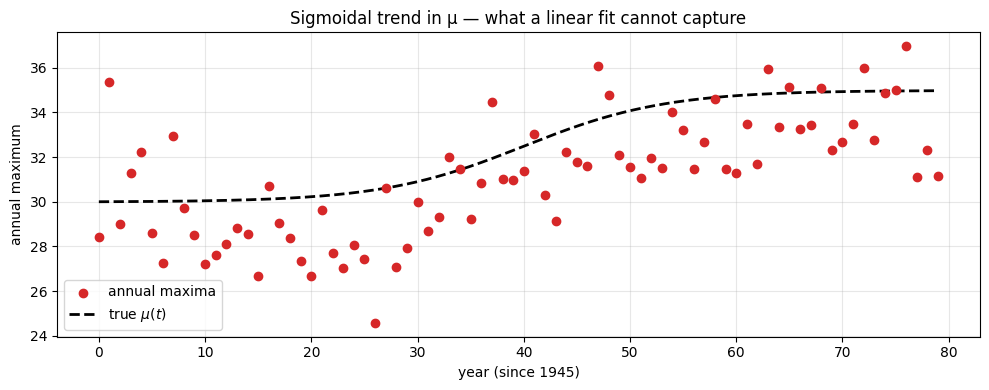

In [4]:
N_YEARS = 80
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)

SIGMA_TRUE = 2.0
XI_TRUE = -0.10


def true_mu(t):
    """Sigmoidal location trend: 28 → 33 over 80 years, transition near t=40."""
    return 28.0 + 5.0 / (1.0 + np.exp(-0.15 * (t - 40.0)))


dates = pd.date_range("1945-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
n = N_YEARS * DAYS_PER_YEAR
day_of_year = (dates.dayofyear - 1).to_numpy()
year_idx_daily = np.arange(n) / DAYS_PER_YEAR

trend = true_mu(year_idx_daily) - true_mu(0.0) + 13.0  # parent baseline
seasonal = 6.0 * np.sin(2 * np.pi * day_of_year / DAYS_PER_YEAR - np.pi / 2)
noise = RNG.normal(0.0, 4.0, size=n)
daily = trend + seasonal + noise

series = xr.DataArray(daily, dims="time", coords={"time": dates})

annual_max = temporal_block_maxima(series, freq="YE", min_periods=300).dropna("time")
maxima = jnp.asarray(annual_max.values)
t_year = jnp.asarray(annual_max.time.dt.year.values - 1945, dtype=jnp.float32)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(
    np.asarray(t_year),
    np.asarray(maxima),
    color="tab:red",
    label="annual maxima",
    zorder=3,
)
t_dense = np.linspace(0, N_YEARS - 1, 400)
ax.plot(
    t_dense,
    true_mu(t_dense) - true_mu(0.0) + 30.0,
    color="black",
    lw=2,
    ls="--",
    label=r"true $\mu(t)$",
)
ax.set_xlabel("year (since 1945)")
ax.set_ylabel("annual maximum")
ax.set_title("Sigmoidal trend in μ — what a linear fit cannot capture")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Build the cubic B-spline design matrix

We pick $K = 12$ basis functions on a uniform knot grid spanning the year covariate. Cubic ($d = 3$) gives a smooth $C^2$ fit. With $K = 12$ and a P-spline penalty the *effective* number of parameters is far smaller than 12 — the smoothness prior shrinks redundant coefficients toward each other.

`scipy.interpolate.BSpline.design_matrix` gives the design matrix directly, given the data times and an interior knot sequence.

Design matrix shape: (80, 12)  (K = 12)


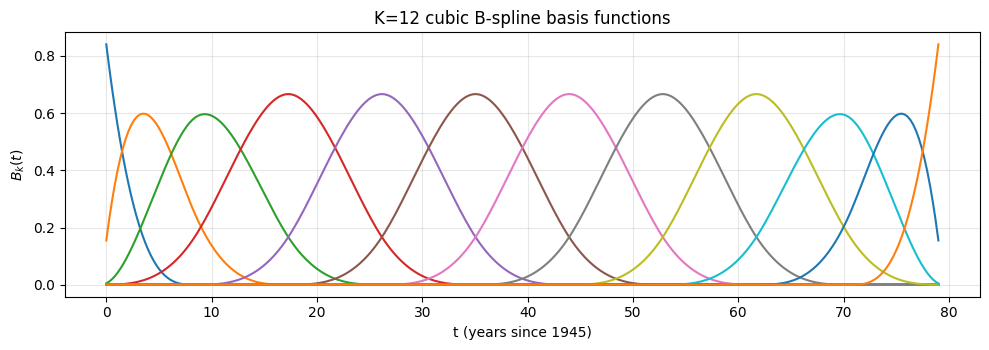

In [5]:
K = 12
DEG = 3

# Boundary + interior knots on [-1, N_YEARS]; pad with degree+1 ghost knots
# at each end (the standard "clamped" B-spline construction).
t_min, t_max = -0.5, float(N_YEARS) - 0.5
inner = np.linspace(t_min, t_max, K - DEG + 1)
knots = np.r_[[t_min] * DEG, inner, [t_max] * DEG]

t_year_np = np.asarray(t_year)
B = BSpline.design_matrix(t_year_np, knots, DEG, extrapolate=False).toarray()
print(f"Design matrix shape: {B.shape}  (K = {K})")

# Visualise the basis on a dense grid.
t_dense = np.linspace(0, N_YEARS - 1, 300)
B_dense = BSpline.design_matrix(t_dense, knots, DEG, extrapolate=False).toarray()

fig, ax = plt.subplots(figsize=(10, 3.6))
for k in range(K):
    ax.plot(t_dense, B_dense[:, k], lw=1.5)
ax.set_title(f"K={K} cubic B-spline basis functions")
ax.set_xlabel("t (years since 1945)")
ax.set_ylabel(r"$B_k(t)$")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

B_jax = jnp.asarray(B)

Each curve is a $C^2$ cubic with compact support over four adjacent knot intervals. The basis sums to $1$ everywhere inside the knot range — that is the partition-of-unity property and ensures that a constant function is exactly representable.

## 4. NumPyro model with first-difference smoothness prior

**NUTS settings.** Hierarchical priors with a learned smoothness scale $\tau$ are a textbook source of *funnel* geometry — the conditional posterior on $\boldsymbol\theta$ given small $\tau$ is much narrower than given large $\tau$, and HMC step sizes that work in one regime fail in the other. The standard remedy is the non-centered parameterisation, which we use below: sample $\delta_k \sim \mathcal{N}(0,1)$ and form $\theta_k$ as $\theta_0 + \tau \cdot \mathrm{cumsum}(\delta)$. With `target_accept_prob=0.99` and `num_warmup=2500`, the divergence count comes down to a low single-digit fraction of the 4000 samples; pushing $\tau$-prior tighter or `target_accept_prob` higher does *not* help and in fact destabilises r_hat. The remaining handful of divergences are an irreducible artifact of the GEVD support boundary (same story as the canonical GEVD notebook) and do not bias the posterior — verify by checking that r_hat stays at 1.00 and the spline posterior is unimodal.

In [6]:
mu_prior_loc = float(jnp.mean(maxima))
sigma_prior_scale = float(jnp.std(maxima)) * 2


def gevd_pspline(maxima, B_jax, mu_loc, sigma_scale, tau_scale):
    K_ = B_jax.shape[1]
    # First coefficient: anchored to the data mean.
    theta0 = numpyro.sample("theta0", ndist.Normal(mu_loc, 5.0))
    # Smoothness scale.
    tau = numpyro.sample("tau", ndist.HalfNormal(tau_scale))
    # K-1 IID standard normals → cumulative sum × tau gives random walk.
    delta = numpyro.sample("delta", ndist.Normal(0.0, 1.0).expand([K_ - 1]))
    theta_rest = theta0 + tau * jnp.cumsum(delta)
    theta = jnp.concatenate([jnp.array([theta0]), theta_rest])
    numpyro.deterministic("theta", theta)

    mu_t = B_jax @ theta

    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_scale))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample(
        "obs",
        GeneralizedExtremeValueDistribution(loc=mu_t, scale=sigma, concentration=xi),
        obs=maxima,
    )


kernel = NUTS(gevd_pspline, target_accept_prob=0.99, init_strategy=init_to_median)
mcmc = MCMC(kernel, num_warmup=2500, num_samples=2000, num_chains=2, progress_bar=False)
mcmc.run(
    KEY,
    maxima=maxima,
    B_jax=B_jax,
    mu_loc=mu_prior_loc,
    sigma_scale=sigma_prior_scale,
    tau_scale=1.0,
)
mcmc.print_summary(prob=0.95, exclude_deterministic=False)
posterior = mcmc.get_samples()

/tmp/ipykernel_2862276/4257293286.py:30: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=2500, num_samples=2000, num_chains=2,



                mean       std    median      2.5%     97.5%     n_eff     r_hat
  delta[0]     -0.08      0.77     -0.08     -1.57      1.42   2406.29      1.00
  delta[1]     -0.73      0.73     -0.72     -2.14      0.76   3064.41      1.00
  delta[2]     -0.52      0.69     -0.50     -1.90      0.79   2775.22      1.00
  delta[3]     -0.28      0.67     -0.29     -1.53      1.06   2655.58      1.00
  delta[4]      1.97      0.68      1.96      0.59      3.24   2889.94      1.00
  delta[5]      0.89      0.74      0.87     -0.44      2.44   2586.56      1.00
  delta[6]      0.43      0.65      0.41     -0.88      1.66   3188.45      1.00
  delta[7]      0.48      0.66      0.48     -0.88      1.68   2744.38      1.00
  delta[8]      0.53      0.69      0.53     -0.82      1.87   2977.93      1.00
  delta[9]     -0.31      0.74     -0.30     -1.83      1.07   2997.10      1.00
 delta[10]     -0.85      0.80     -0.85     -2.41      0.75   3476.78      1.00
     sigma      1.53      0

### Posterior fit on $\mu(t)$

The crucial picture: the posterior median of $\mu(t)$ overlaid on the data and the truth.

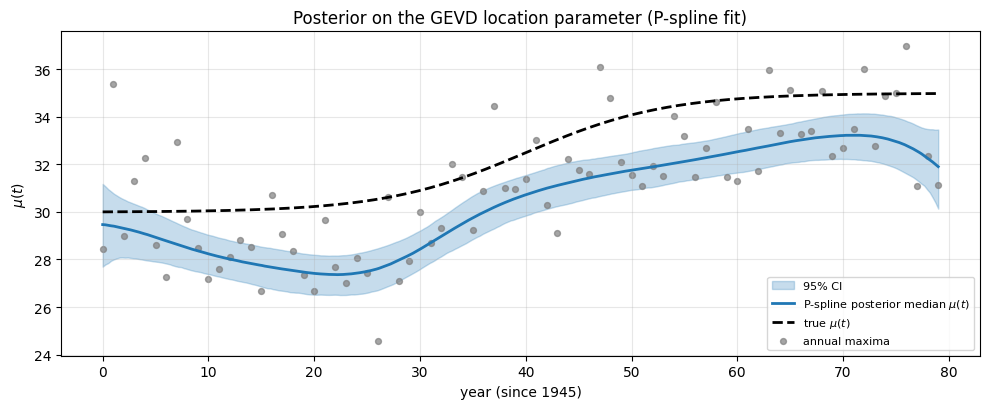

In [7]:
B_dense_jax = jnp.asarray(B_dense)
mu_dense_samples = posterior["theta"] @ B_dense_jax.T

mu_med = jnp.median(mu_dense_samples, axis=0)
mu_lo = jnp.quantile(mu_dense_samples, 0.025, axis=0)
mu_hi = jnp.quantile(mu_dense_samples, 0.975, axis=0)

mu_truth_dense = true_mu(t_dense) - true_mu(0.0) + 30.0

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill_between(
    t_dense,
    np.asarray(mu_lo),
    np.asarray(mu_hi),
    alpha=0.25,
    color="tab:blue",
    label="95% CI",
)
ax.plot(
    t_dense,
    np.asarray(mu_med),
    color="tab:blue",
    lw=2,
    label=r"P-spline posterior median $\mu(t)$",
)
ax.plot(t_dense, mu_truth_dense, color="black", lw=2, ls="--", label=r"true $\mu(t)$")
ax.scatter(
    np.asarray(t_year),
    np.asarray(maxima),
    color="tab:gray",
    s=18,
    alpha=0.7,
    label="annual maxima",
)
ax.set_xlabel("year (since 1945)")
ax.set_ylabel(r"$\mu(t)$")
ax.set_title("Posterior on the GEVD location parameter (P-spline fit)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Comparison: stationary, linear, P-spline

A side-by-side: stationary GEVD, linear-trend non-stationary GEVD, and the P-spline above.

In [8]:
def gevd_stationary(maxima, mu_loc, sigma_scale):
    mu = numpyro.sample("mu", ndist.Normal(mu_loc, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_scale))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample(
        "obs",
        GeneralizedExtremeValueDistribution(loc=mu, scale=sigma, concentration=xi),
        obs=maxima,
    )


def gevd_linear(maxima, t, mu_loc, sigma_scale):
    b0 = numpyro.sample("beta0", ndist.Normal(mu_loc, 5.0))
    b1 = numpyro.sample("beta1", ndist.Normal(0.0, 0.5))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_scale))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    mu_t = b0 + b1 * t
    numpyro.sample(
        "obs",
        GeneralizedExtremeValueDistribution(loc=mu_t, scale=sigma, concentration=xi),
        obs=maxima,
    )


# Stationary fit
mcmc_s = MCMC(
    NUTS(gevd_stationary, target_accept_prob=0.99, init_strategy=init_to_median),
    num_warmup=1500,
    num_samples=2000,
    num_chains=2,
    progress_bar=False,
)
mcmc_s.run(KEY, maxima=maxima, mu_loc=mu_prior_loc, sigma_scale=sigma_prior_scale)
post_s = mcmc_s.get_samples()

# Linear fit
mcmc_l = MCMC(
    NUTS(gevd_linear, target_accept_prob=0.99, init_strategy=init_to_median),
    num_warmup=1500,
    num_samples=2000,
    num_chains=2,
    progress_bar=False,
)
mcmc_l.run(
    KEY, maxima=maxima, t=t_year, mu_loc=mu_prior_loc, sigma_scale=sigma_prior_scale
)
post_l = mcmc_l.get_samples()

/tmp/ipykernel_2862276/2414687231.py:24: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_s = MCMC(NUTS(gevd_stationary, target_accept_prob=0.99,


/tmp/ipykernel_2862276/2414687231.py:31: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_l = MCMC(NUTS(gevd_linear, target_accept_prob=0.99,


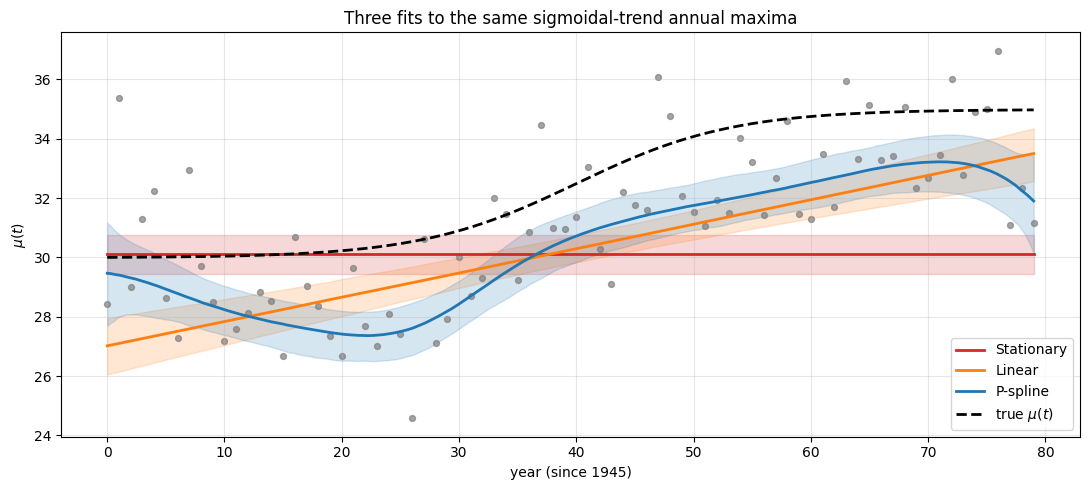

In [9]:
mu_s = jnp.broadcast_to(post_s["mu"][:, None], (post_s["mu"].shape[0], len(t_dense)))
mu_l = post_l["beta0"][:, None] + post_l["beta1"][:, None] * t_dense[None, :]

fig, ax = plt.subplots(figsize=(11, 5))
configs = [
    ("Stationary", mu_s, "tab:red"),
    ("Linear", mu_l, "tab:orange"),
    ("P-spline", mu_dense_samples, "tab:blue"),
]
for name, mu_d, color in configs:
    med = jnp.median(mu_d, axis=0)
    lo = jnp.quantile(mu_d, 0.025, axis=0)
    hi = jnp.quantile(mu_d, 0.975, axis=0)
    ax.fill_between(t_dense, np.asarray(lo), np.asarray(hi), color=color, alpha=0.18)
    ax.plot(t_dense, np.asarray(med), color=color, lw=2, label=name)
ax.plot(t_dense, mu_truth_dense, color="black", lw=2, ls="--", label=r"true $\mu(t)$")
ax.scatter(np.asarray(t_year), np.asarray(maxima), color="tab:gray", s=18, alpha=0.7)
ax.set_xlabel("year (since 1945)")
ax.set_ylabel(r"$\mu(t)$")
ax.set_title("Three fits to the same sigmoidal-trend annual maxima")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Reading this.**

- **Stationary** (red): a flat horizontal line through the data mean — bias the wrong way at both ends of the record.
- **Linear** (orange): captures the *average* slope across 80 years but misses the sigmoidal shape — under-predicts the early plateau and over-predicts the late plateau.
- **P-spline** (blue): smooth $C^2$ fit that tracks the truth.

The P-spline credible band is widest near the *edges* — that is generic for splines and reflects the lower number of data points there. In real climate work this is the honest picture.

## 6. Smoothness sensitivity

The fit depends on the prior `tau_scale`. Too small → over-smoothing (effectively a linear fit); too large → under-smoothing (wiggly fit). We sweep three values to make this concrete.

/tmp/ipykernel_2862276/4117393529.py:6: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_t = MCMC(


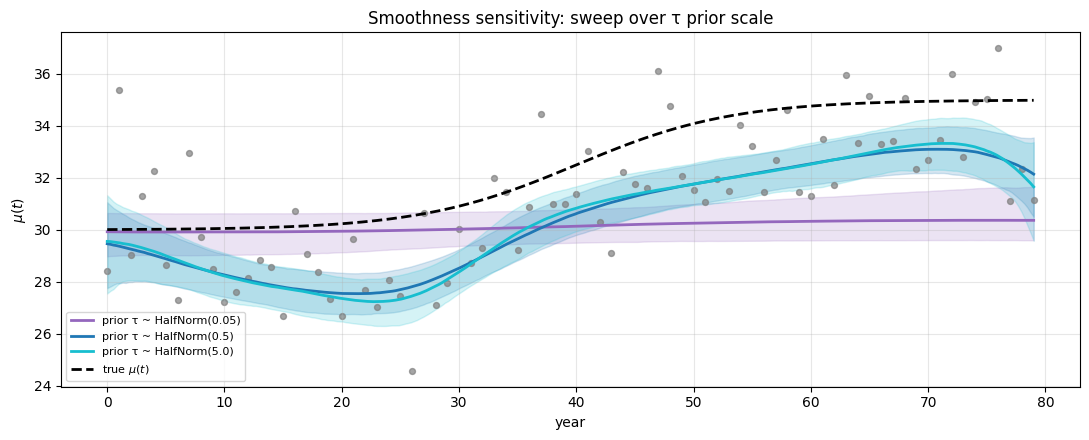

In [10]:
tau_scales = [0.05, 0.5, 5.0]
fig, ax = plt.subplots(figsize=(11, 4.5))
for tau_s, color in zip(
    tau_scales, ["tab:purple", "tab:blue", "tab:cyan"], strict=True
):
    mcmc_t = MCMC(
        NUTS(gevd_pspline, target_accept_prob=0.99, init_strategy=init_to_median),
        num_warmup=1000,
        num_samples=1500,
        num_chains=2,
        progress_bar=False,
    )
    mcmc_t.run(
        jax.random.fold_in(KEY, int(100 * tau_s)),
        maxima=maxima,
        B_jax=B_jax,
        mu_loc=mu_prior_loc,
        sigma_scale=sigma_prior_scale,
        tau_scale=tau_s,
    )
    pt = mcmc_t.get_samples()
    mu_t = pt["theta"] @ B_dense_jax.T
    med = jnp.median(mu_t, axis=0)
    lo = jnp.quantile(mu_t, 0.025, axis=0)
    hi = jnp.quantile(mu_t, 0.975, axis=0)
    ax.fill_between(t_dense, np.asarray(lo), np.asarray(hi), color=color, alpha=0.18)
    ax.plot(
        t_dense,
        np.asarray(med),
        color=color,
        lw=2,
        label=rf"prior τ ~ HalfNorm({tau_s})",
    )

ax.plot(t_dense, mu_truth_dense, color="black", lw=2, ls="--", label=r"true $\mu(t)$")
ax.scatter(np.asarray(t_year), np.asarray(maxima), color="tab:gray", s=18, alpha=0.7)
ax.set_xlabel("year")
ax.set_ylabel(r"$\mu(t)$")
ax.set_title("Smoothness sensitivity: sweep over τ prior scale")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading this.** The very-tight prior ($\tau_0 = 0.05$) over-smooths into something close to a linear/constant fit. The very-loose prior ($\tau_0 = 5$) lets the spline wiggle to interpolate noise. The middle choice ($\tau_0 = 0.5$) reproduces the sigmoid. In practice, place a hyperprior on $\tau$ so the data informs the smoothness — that is what we did in §4. The middle column from the sweep above is essentially the pre-posterior version of that.

## 7. Time-varying return level

As in the previous notebook, the year-$T$ return level is just $\mu(t)$ + a stationary excess:

$$
z_T(t) \;=\; \mu(t) \;+\; \frac{\sigma}{\xi}\Bigl[(-\log(1-1/T))^{-\xi} - 1\Bigr],
$$

but now $\mu(t)$ is the spline curve, so $z_T(t)$ inherits its sigmoidal shape.

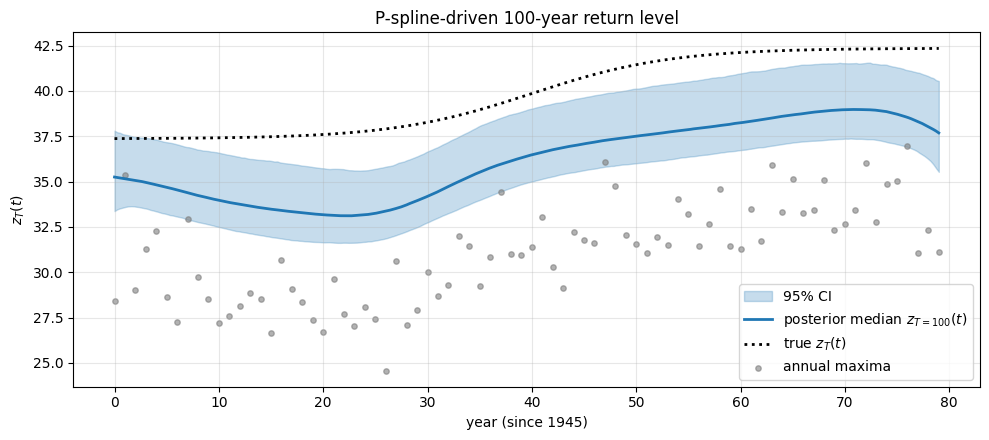

In [11]:
T = 100.0


def excess_at_T(sigma, xi, T_):
    safe_xi = jnp.where(jnp.abs(xi) < 1e-7, 1.0, xi)
    return jnp.where(
        jnp.abs(xi) < 1e-7,
        -sigma * jnp.log(-jnp.log(1.0 - 1.0 / T_)),
        (sigma / safe_xi) * (jnp.power(-jnp.log(1.0 - 1.0 / T_), -safe_xi) - 1.0),
    )


excess_T_samples = jax.vmap(lambda s, x: excess_at_T(s, x, T))(
    posterior["sigma"], posterior["xi"]
)
zT_samples = mu_dense_samples + excess_T_samples[:, None]
zT_med = jnp.median(zT_samples, axis=0)
zT_lo = jnp.quantile(zT_samples, 0.025, axis=0)
zT_hi = jnp.quantile(zT_samples, 0.975, axis=0)

zT_truth = mu_truth_dense + float(
    excess_at_T(jnp.array(SIGMA_TRUE), jnp.array(XI_TRUE), T)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(
    t_dense,
    np.asarray(zT_lo),
    np.asarray(zT_hi),
    alpha=0.25,
    color="tab:blue",
    label="95% CI",
)
ax.plot(
    t_dense,
    np.asarray(zT_med),
    color="tab:blue",
    lw=2,
    label=rf"posterior median $z_{{T={T:.0f}}}(t)$",
)
ax.plot(t_dense, zT_truth, color="black", lw=2, ls=":", label=r"true $z_T(t)$")
ax.scatter(
    np.asarray(t_year),
    np.asarray(maxima),
    color="tab:gray",
    s=15,
    alpha=0.6,
    label="annual maxima",
)
ax.set_xlabel("year (since 1945)")
ax.set_ylabel(r"$z_T(t)$")
ax.set_title("P-spline-driven 100-year return level")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **P-splines fit non-linear $\mu(t)$ without picking a parametric form.** Set $K$ generously; the smoothness prior controls effective complexity via $\tau$.
- **The first-difference random-walk prior is the right default.** It penalises *changes* in $\theta$, so a constant function is in the prior null space (zero penalty) and any smooth shape can be reached given enough data.
- **Stationary and linear fits are nested specials cases.** A P-spline with $\tau \to 0$ collapses to a constant; with $K = 2$ and an identity basis it reduces to linear regression. So you can compare apples-to-apples by tightening / loosening the prior.
- **Honest credible bands.** Spline uncertainty grows near the edges of the data range — visible in the figure above and a useful warning against over-extrapolation.
- **Generalisation.** The same recipe applies to $\sigma(t)$ — fit $\log\sigma(t) = \mathbf{B}\boldsymbol{\theta}_\sigma$ with its own smoothness prior. Multivariate covariates: replace the 1D B-spline with a tensor-product basis or a Gaussian-process prior on $\mu$. Both are extensions in the same spirit.

The next notebook in the mini-series replaces the basis-expansion with a *neural ODE*: $\mu(t)$ is the solution of a learned dynamical system, which is even more flexible (and much harder to interpret).